
**CLASSIFICATION**

In [ ]:
from sklearn.datasets import fetch_openml
import numpy as np
mnist = fetch_openml('mnist_784')
X = mnist.data.to_numpy()/255.0
Y = mnist.target.to_numpy()
Y = np.array(Y, dtype=np.int8)
print('Dim X: ' + str(X.shape))
print('Dim Y: ' + str(Y.shape))

Dim X: (70000, 784)
Dim Y: (70000,)


In [ ]:
from sklearn.model_selection import train_test_split
X,  _ , Y,  _  = train_test_split(X, Y, train_size=5000, random_state=0)
X, XT , Y, YT  = train_test_split(X, Y, train_size= 300, random_state=0)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.tree import plot_tree
def quality(M,XT,YT):
  Yp = M.predict(XT)
  print('ACC: ' + format(accuracy_score(YT,Yp),".3f"))
  print('BAC: ' + format(balanced_accuracy_score(YT,Yp),".3f"))
  print('CM: \n' + str(confusion_matrix(YT,Yp)))

In [ ]:
from sklearn.svm import SVC
grid = {'C':      np.logspace(-4, 3, 9),
        'kernel': ['linear']}
M = GridSearchCV(estimator  = SVC(),
                 param_grid = grid,
                 cv         = 3,
                 scoring    = 'accuracy')
M.fit(X,Y);
print('C best: '      + str(M.best_params_['C']))
print('kernel best: ' + str(M.best_params_['kernel']))
quality(M,XT,YT)

C best: 0.31622776601683794
kernel best: linear
ACC: 0.830
BAC: 0.826
CM: 
[[409   0  12   1   0   9   8   0   1   0]
 [  0 532   1   0   1   3   1   1   1   1]
 [ 10  22 375  10   9   3  11  15   4  10]
 [  3   4  23 406   1  17   3   7   4  15]
 [  2   0   2   0 380   0   5   1   1  48]
 [ 18  11   7  71   7 247  21   8  24  22]
 [  6   0  18   0   5   8 450   0   6   2]
 [  3  20   2   4   8   2   1 421   1  22]
 [  3  30  20  49   5   9  10   4 325  16]
 [  3   1   0   9  47   5   0  19   1 357]]


In [ ]:
from sklearn.svm import SVC
grid = {'C':      np.logspace(-4, 3, 9),
        'kernel': ['rbf'],
        'gamma' : np.logspace(-4, 3, 9)}
M = GridSearchCV(estimator  = SVC(),
                 param_grid = grid,
                 cv         = 3,
                 scoring    = 'accuracy')
M.fit(X,Y);
print('C best: '      + str(M.best_params_['C']))
print('kernel best: ' + str(M.best_params_['kernel']))
print('gamma best: '  + str(M.best_params_['gamma']))
quality(M,XT,YT)

C best: 17.78279410038923
kernel best: rbf
gamma best: 0.005623413251903491
ACC: 0.854
BAC: 0.851
CM: 
[[411   0  13   0   0   8   6   0   2   0]
 [  0 533   1   1   1   0   1   1   0   3]
 [  7  17 385  13   9   1   8  16   4   9]
 [  2   4  22 417   1  13   4   6   2  12]
 [  2   1   1   0 389   0   5   1   1  39]
 [ 13   6   4  70   6 263  19  10  26  19]
 [  6   0   8   0   4   5 467   0   3   2]
 [  3  16   2   2   5   1   2 430   0  23]
 [  2  23  14  47   4   7   7   2 350  15]
 [  4   1   0  10  33   4   0  19   0 371]]


max_depth best: 20
ACC: 0.548
BAC: 0.540
CM: 
[[313   9  23  16   7   9  14  42   1   6]
 [  0 453   0  15   1  41   9   8   9   5]
 [ 15  50 222  58  20   8  25  14  22  35]
 [  6  14  35 304  23  13  13  42  18  15]
 [ 13   1  18   8 225  13  16  57  40  48]
 [ 63  13   9  73  48  82  23  44  21  60]
 [ 23  12  34  17  29  28 296  11  30  15]
 [ 12  10  36  21  15  25  11 298  13  43]
 [ 14  28  50  61  34  15  39  18 180  32]
 [  9   3  14  32  83   7  16  60  16 202]]


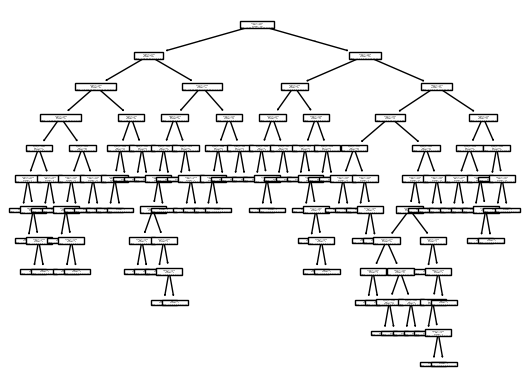

In [ ]:
from sklearn.tree import DecisionTreeClassifier
grid = {'max_depth': [2,4,6,8,12,16,20,30]}
M = GridSearchCV(estimator  = DecisionTreeClassifier(),
                 param_grid = grid,
                 cv         = 3,
                 scoring    = 'accuracy')
M.fit(X,Y);
print('max_depth best: ' + str(M.best_params_['max_depth']))
plot_tree(M.best_estimator_)
quality(M,XT,YT)

min_samples_leaf best: 4
ACC: 0.534
BAC: 0.529
CM: 
[[303  32  21  16   7  11   8  37   3   2]
 [  0 426  36  12   8  48   1   5   2   3]
 [ 53  36 272  33  31  16   7  12   4   5]
 [ 13  35  39 288  35  32   2  18   5  16]
 [ 41   4  17   6 248  29  16  21  23  34]
 [ 74  18  13  76  49  91  10  36  11  58]
 [ 33   2  47  25  48  44 273  15   2   6]
 [ 27  37  26   0  14  92   2 226   5  55]
 [ 35  26  50  54  49  29  18  18 166  26]
 [ 24   5  13  32  60  13  13  52  13 217]]


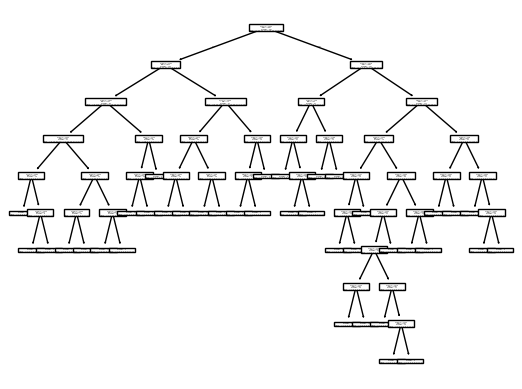

In [ ]:
from sklearn.tree import DecisionTreeClassifier
grid = {'min_samples_leaf': [2,4,6,8,12,16,20,30]}
M = GridSearchCV(estimator  = DecisionTreeClassifier(),
                 param_grid = grid,
                 cv         = 3,
                 scoring    = 'accuracy')
M.fit(X,Y);
print('min_samples_leaf best: ' + str(M.best_params_['min_samples_leaf']))
plot_tree(M.best_estimator_)
quality(M,XT,YT)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
M = RandomForestClassifier(n_estimators=300)
M.fit(X,Y);
quality(M,XT,YT)

ACC: 0.821
BAC: 0.816
CM: 
[[423   0   7   3   0   0   6   1   0   0]
 [  0 527   4   1   1   0   1   2   2   3]
 [ 12  17 391  13   8   0   7  12   4   5]
 [  3   8  15 433   0   4   4   5   4   7]
 [  3   3   0   0 383   0   9   1   7  33]
 [ 25  13   7  94  13 215  17  10  13  29]
 [ 11   8  23   2   9   5 436   0   1   0]
 [  4  22  11   6   5   0   1 405   2  28]
 [  3  35  19  54   8   4   3   0 316  29]
 [  4   4   2  10  75   1   0  15   2 329]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
grid = {'n_estimators': [300],
        'max_features': [10,16,20,28,32,40]}
M = GridSearchCV(estimator  = RandomForestClassifier(),
                 param_grid = grid,
                 cv         = 3,
                 scoring    = 'accuracy')
M.fit(X,Y);
print('n_estimators best: ' + str(M.best_params_['n_estimators']))
print('max_features best: ' + str(M.best_params_['max_features']))
quality(M,XT,YT)

n_estimators best: 300
max_features best: 16
ACC: 0.818
BAC: 0.813
CM: 
[[417   1   7   5   1   2   7   0   0   0]
 [  0 533   1   1   1   0   1   1   0   3]
 [  9  12 395  12   9   0   9  13   5   5]
 [  4   7  19 430   0   6   4   5   1   7]
 [  2   6   1   1 374   0   7   1   2  45]
 [ 25  15  13  97  11 203  17  10  12  33]
 [ 14  11  25   0  10   6 428   0   1   0]
 [  5  24   6   2   4   0   1 415   1  26]
 [  1  36  19  63  10   2   4   1 310  25]
 [  4   5   0   9  70   2   0  11   0 341]]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
grid = {'n_estimators':  [300],
        'learning_rate': [0.001, 0.005, .01, 0.05, .1]}
M = GridSearchCV(estimator  = GradientBoostingClassifier(),
                 param_grid = grid,
                 cv         = 3,
                 scoring    = 'accuracy')
M.fit(X,Y);
print('n_estimators best:  ' + str(M.best_params_['n_estimators']))
print('learning_rate best: ' + str(M.best_params_['learning_rate']))
quality(M,XT,YT)